# 2. PLD Experiment Design

In [2]:
%load_ext autoreload
%autoreload 2
import os
os.environ['ETS_TOOLKIT'] = 'null'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sns
from pathlib import Path

from m3util.viz.layout import layout_fig
from m3util.viz.text import labelfigs
from sro_sto_plume import microscopy as mic
from sro_sto_plume.plot_target import plot_target_microscopy_std
from m3util.viz.printing import printer
printing = printer(basepath='../figures/', fileformats=['png','svg','tif'], dpi=600)

ModuleNotFoundError: No module named 'sro_sto_plume'

## Figure 1: Experiment Setup

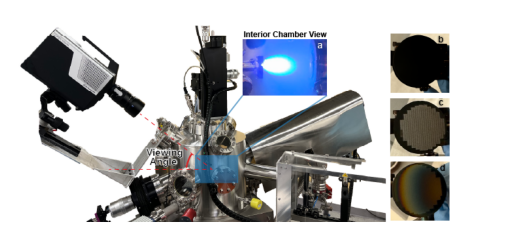

In [10]:
plt.imshow(plt.imread('../figures/Figure1-Samples_experiment_setup.png'))
plt.axis('off')
plt.show()

Fig. 1 Pulsed laser deposition setup with plume recording camera, and experiment design. a   

## 3D confocal microscopy scans of target surface for different samples

This part loads the full-area height maps exported as TXT files, flattens them (optional), and reports roughness in two ways:

1. Treat every pixel across all images in a folder as a single surface and compute Ra/Rq/Rz.
2. Compute the mean height of each image, then evaluate the variation of those means (image-to-image roughness).

Update the configuration below to point at the folders you would like to compare.

In [4]:
# --- Configuration ---
DATA_FOLDERS = [
    {"name": "Sanded", "path": Path("../data/TargetMicroscopy/Sanded/"), "loader": "datx", "pattern": "*.datx"},
    {"name": "G1", "path": Path("../data/TargetMicroscopy/G1/"), "loader": "datx", "pattern": "*.datx"},
    {"name": "G2", "path": Path("../data/TargetMicroscopy/G2/"), "loader": "datx", "pattern": "*.datx"},
    {"name": "G3", "path": Path("../data/TargetMicroscopy/G3/"), "loader": "datx", "pattern": "*.datx"},
    {"name": "G4", "path": Path("../data/TargetMicroscopy/G4/"), "loader": "datx", "pattern": "*.datx"},
    {"name": "G5", "path": Path("../data/TargetMicroscopy/G5/"), "loader": "datx", "pattern": "*.datx"},
]
PATTERN = "*.datx"           # default glob pattern
DETREND = False              # remove best-fit plane before computing roughness, ignore global tilt but might remove real features
ZERO_CENTER = True           # subtract per-image mean (after detrend)
HEIGHT_SCALE = 1e6           # meters -> micrometers
HEIGHT_UNIT = "µm"

## Compute batch roughness statistics

For each folder, the code below:

- loads all TXT files matching `PATTERN`,
- optionally detrends each map,
- records per-image roughness metrics,
- aggregates across all pixels,
- computes image-to-image variation (based on the mean height per image).

In [5]:
folder_summaries = []
mean_summaries = []
rq_variation_summaries = []
per_image_frames = []

maps_all = {}
for entry in DATA_FOLDERS:
    folder_name = entry["name"]
    folder_path = entry["path"]
    loader = entry.get("loader", "txt")
    dataset_keyword = entry.get("dataset_keyword", "Surface")
    pattern = entry.get("pattern", PATTERN)

    try:
        maps, global_stats, mean_stats, rq_stats, per_image_df = mic.analyze_area_folder(
            folder_path,
            name=folder_name,
            pattern=pattern,
            loader=loader,
            dataset_keyword=dataset_keyword,
            detrend=DETREND,
            zero_center=ZERO_CENTER,
            scale=HEIGHT_SCALE,
            unit=HEIGHT_UNIT,
        )
        maps_all[folder_name] = maps
    except ValueError as exc:
        print(f"[WARN] {exc}")
        continue

    folder_summaries.append(global_stats)
    mean_summaries.append(mean_stats)
    rq_variation_summaries.append(rq_stats)
    per_image_frames.append(per_image_df)

if not folder_summaries:
    raise ValueError("No folders produced data. Check DATA_FOLDERS and PATTERN.")

folder_df = pd.DataFrame(folder_summaries).set_index("folder")
mean_df = pd.DataFrame(mean_summaries).set_index("folder")
rq_variation_df = pd.DataFrame(rq_variation_summaries).set_index("folder")
per_image_df = pd.concat(per_image_frames, ignore_index=True)

print("Global pixel-wise roughness (all pixels pooled)")
display(folder_df[["mean", "Ra", "Rq", "Rz", "count", "n_images", "unit"]])

print("Per-image Rq variation (within folders)")
display(rq_variation_df[["mean", "std", "min", "max", "range", "cv", "count", "unit"]])

print("Image-to-image variation (based on image means)")
display(mean_df[["mean", "Ra", "Rq", "Rz", "count", "unit"]])

print("Per-image roughness metrics")
display(per_image_df[["folder", "path", "mean", "Ra", "Rq", "Rz", "count", "unit"]])


Global pixel-wise roughness (all pixels pooled)


,mean,Ra,Rq,Rz,count,n_images,unit
folder,,,,,,,
Sanded,1.013192e-14,5.821114,7.156484,65.567904,4797410,5,µm
G1,-9.777299e-15,5.662267,6.924928,99.866597,3264594,4,µm
G2,-5.372150e-15,5.812391,7.037946,105.024678,3479683,5,µm
G3,-8.268471e-15,5.049495,6.236913,100.518558,2353534,4,µm
G4,3.108059e-15,5.235564,6.464666,97.342273,2689105,4,µm
G5,1.999848e-16,6.451515,7.948429,97.969771,2775769,4,µm


Per-image Rq variation (within folders)


,mean,std,min,max,range,cv,count,unit
folder,,,,,,,,
Sanded,7.030026,1.329747,5.386655,8.952341,3.565686,0.189152,5,µm
G1,6.901704,0.829705,5.581450,7.769922,2.188472,0.120217,4,µm
G2,7.047319,0.540399,6.283902,7.729875,1.445973,0.076681,5,µm
G3,6.218629,0.443063,5.681770,6.880894,1.199124,0.071248,4,µm
G4,6.456054,0.434307,5.955057,7.119800,1.164744,0.067271,4,µm
G5,7.933292,0.463440,7.365984,8.565597,1.199614,0.058417,4,µm


Image-to-image variation (based on image means)


,mean,Ra,Rq,Rz,count,unit
folder,,,,,,
Sanded,1.061438e-14,1.647588e-14,1.767566e-14,4.629370e-14,5,µm
G1,-8.941178e-15,1.296654e-14,1.403310e-14,3.662411e-14,4,µm
G2,-5.040887e-15,1.127850e-14,1.300981e-14,3.634345e-14,5,µm
G3,-7.785107e-15,4.551497e-15,5.339749e-15,1.468181e-14,4,µm
G4,2.778611e-15,9.602738e-15,1.093417e-14,2.881652e-14,4,µm
G5,2.793512e-16,5.103968e-15,6.250527e-15,1.571395e-14,4,µm


Per-image roughness metrics


,folder,path,mean,Ra,Rq,Rz,count,unit
0,Sanded,../data/TargetMicroscopy/Sanded/s1.datx,3.837258e-14,4.273773,5.386655,43.598751,971868,µm
1,Sanded,../data/TargetMicroscopy/Sanded/s2.datx,-2.002463e-15,4.704060,5.825871,57.101105,943395,µm
2,Sanded,../data/TargetMicroscopy/Sanded/s3.datx,-6.466023e-15,7.505029,8.952341,60.706878,954014,µm
3,Sanded,../data/TargetMicroscopy/Sanded/s4.datx,2.135101e-14,6.798546,8.025161,49.314161,978549,µm
4,Sanded,../data/TargetMicroscopy/Sanded/s6.datx,-1.812210e-15,5.815521,6.960102,51.616192,949584,µm
5,G1,../data/TargetMicroscopy/G1/s1.datx,6.991734e-15,5.686941,6.849692,92.778080,836629,µm
6,G1,../data/TargetMicroscopy/G1/s4.datx,-2.008954e-15,6.340901,7.769922,84.165883,801324,µm
7,G1,../data/TargetMicroscopy/G1/s5.datx,-1.746456e-14,6.129036,7.405754,91.238610,770191,µm
8,G1,../data/TargetMicroscopy/G1/s8.datx,-2.806507e-14,4.583453,5.581450,78.845310,856450,µm
9,G2,../data/TargetMicroscopy/G2/s2.datx,-2.382220e-14,5.065815,6.283902,90.068571,710137,µm


## Visual comparisons

Bar plots and strip plots make it easier to compare roughness across folders.

../figures/FigureS1-TargetMicroscopy.png
../figures/FigureS1-TargetMicroscopy.svg
../figures/FigureS1-TargetMicroscopy.tif


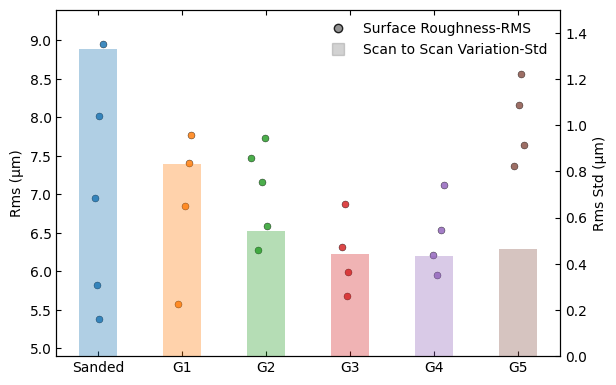

In [ ]:
base = colormaps.get_cmap("tab10").colors[:5]
colors = [(0, 0, 0), *base]
order = folder_df.index.tolist()

fig, ax_scatter, ax_std = plot_target_microscopy_std(per_image_df, rq_variation_df, order, HEIGHT_UNIT)
printing.savefig(fig, 'FigureS1-TargetMicroscopy')
plt.show()

### Plottings of all microscopy scans

In [1]:
fig, axes = layout_fig(graph=5*6, mod=5, figsize=(12, 13), layout='tight')    

label_index = 0
for row, key in enumerate(maps_all.keys()):
    maps = maps_all[key]
    if len(maps) < 5:
        for ax in axes[row*5+len(maps): row*5+5]:
            ax.remove()
    
    for i, map in enumerate(maps):
        index = row*5 + i
        ax = axes[index]
        
        data_row = per_image_df.loc[per_image_df["folder"] == key, "Rq"]
        rms = data_row.iloc[i]
        
        # --- Handle NaNs in the map for visualization ---
        filled = map.copy()
        nan_mask = ~np.isfinite(filled)
        filled[nan_mask] = np.nanmedian(filled)

        im = ax.imshow(filled, cmap='viridis')
        labelfigs(ax, label_index, style='b', loc='tl', inset_fraction=(0.1, 0.1), size=12)
        label_index += 1
        labelfigs(ax, None, style='b', loc='tr', inset_fraction=(0.15, 0.22), size=7,
                  string_add=f"{key}-{i+1}\n {rms:.3f} {HEIGHT_UNIT}\n")
        ax.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])
        
        from matplotlib.ticker import ScalarFormatter
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))  # always scientific
        cbar.ax.yaxis.set_major_formatter(formatter)
        cbar.ax.yaxis.get_offset_text().set_visible(True)  # optional: show the ×10^… factor
        
printing.savefig(fig, 'FigureS2-TargetMicroscopy-Maps')
plt.show()

NameError: name 'layout_fig' is not defined

In [3]:
pwd

'/mnt/c/Users/yichen/Lehigh University Dropbox/Yichen Guo/SrRuO3_Plume_Dynamics/notebooks'